# Gradient Descent: Theory

> 📖 Book: [ch04 – Linear regression & descent methods](../../.claude/skills/ml-knowledge/chapters/ch04-linear-regression-gradient-descent.md) · Prev: [01](01_normal_equations.ipynb) · Next: [03 Fixed step](03_gd_fixed_step.ipynb)

The normal equations are easy to understand, but they have drawbacks in practical ML:

- They are slow for large matrices. For big systems it is better to use iterative methods (Jacobi, Gauss–Seidel, SOR, conjugate gradient) that never form the (pseudo)inverse.
- They do not generalize to nonlinear models, which are common in practice.

## The objective function

Gradient methods are effective in speed, memory, stability and accuracy. The least-squares solution minimizes the objective (cost) function

$$
J(\theta) = \frac12\sum_{i=1}^m \left(h_\theta(x^{(i)}) - y^{(i)}\right)^2 = \frac12\|X\theta - y\|^2 .
$$

This is the **squared error**; dividing by $m$ gives the mean squared error (MSE). The $\frac12$ is a convenience that cancels the 2 from differentiating the square.

## The direction of steepest descent

A function has a local minimum or maximum where its [gradient](https://en.wikipedia.org/wiki/Gradient) is zero. A simple strategy to reach a minimum is to walk, step by step, downhill along the steepest direction. Consider the [directional derivative](https://en.wikipedia.org/wiki/Directional_derivative) of $J$ along a unit vector $u$:

$$
\frac{\partial J}{\partial u} = \nabla J \cdot u = \|\nabla J\|\cos\beta ,
$$

where $\beta$ is the angle between $\nabla J$ and $u$. It is largest for $\beta = 0$ ($u$ along the gradient): the gradient is the direction of **steepest ascent**, and

$$
u = -\frac{\nabla J(\theta)}{\|\nabla J(\theta)\|}
$$

is the direction of **steepest descent**.

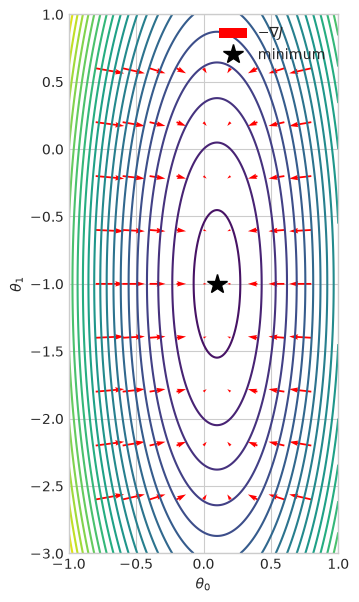

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

# The gradient is perpendicular to the level curves and points uphill
A = np.array([[10.0, 0.0], [0.0, 1.0]])
b = np.array([1.0, -1.0])
T0, T1 = np.meshgrid(np.linspace(-1, 1, 200), np.linspace(-3, 1, 200))
J = 5 * T0**2 + 0.5 * T1**2 - T0 + T1
g0, g1 = np.meshgrid(np.linspace(-0.8, 0.8, 9), np.linspace(-2.6, 0.6, 9))
G0, G1 = 10 * g0 - 1, g1 + 1  # grad J = A theta - b

fig, ax = plt.subplots(figsize=(5, 7))
ax.contour(T0, T1, J, levels=25, cmap="viridis")
ax.quiver(g0, g1, -G0, -G1, color="r", angles="xy", label=r"$-\nabla J$")
ax.plot(0.1, -1, "k*", ms=15, label="minimum")
ax.set(xlabel=r"$\theta_0$", ylabel=r"$\theta_1$", aspect="equal")
ax.legend()
plt.show()

For univariate linear regression the gradient is

$$
\nabla J(\theta) = \begin{pmatrix} \dfrac{\partial J}{\partial \theta_0} \\[2mm] \dfrac{\partial J}{\partial \theta_1} \end{pmatrix}
= \begin{pmatrix} \sum_{i=1}^m \left(h_\theta(x^{(i)}) - y^{(i)}\right) \\ \sum_{i=1}^m \left(h_\theta(x^{(i)}) - y^{(i)}\right)x^{(i)} \end{pmatrix},
$$

and in general, for $n$ features,

$$
\frac{\partial J}{\partial \theta_j} = \sum_{i=1}^m \left(h_\theta(x^{(i)}) - y^{(i)}\right)x_j^{(i)}, \quad j = 0, 1, \dots, n
\qquad\Longleftrightarrow\qquad
\nabla J(\theta) = X^T(X\theta - y),
$$

where $x_j^{(i)}$ is the $j$-th component of $x^{(i)}$ (row $i$ of $X$).

Two questions remain:

1. Does the gradient at a point on the surface point to the minimum? (Not in general – only on perfectly round bowls.)
2. How far should we move along it before stopping?

## The gradient descent algorithm

Define $A = X^TX$ and $b = X^Ty$, so the normal equations read $A\theta = b$ and the gradient is

$$
\nabla J(\theta) = A\theta - b .
$$

Solving $A\theta = b$ is equivalent to finding the minimum of the paraboloid

$$
z = \frac12\theta^TA\theta - b^T\theta + c ,
$$

a convex surface with a single global minimum. We descend from a starting point along $-\nabla J$:

1. Pick a starting point $\hat\theta^{(0)}$.
2. Find a direction in which $J$ decreases.
3. Move an appropriate amount in that direction to get a new approximation.
4. Repeat until convergence.

$$
\boxed{\hat\theta^{(k+1)} = \hat\theta^{(k)} - \alpha\,\nabla J(\hat\theta^{(k)})}
$$

$\alpha > 0$ is the **learning rate**. The update must be **simultaneous**: compute the whole gradient with the old $\theta$, then update every $\theta_j$. A general algorithm needs: a start $\hat\theta^{(0)}$, the data $X$, $y$, the step $\alpha$, the gradient $\nabla J$, a maximum number of iterations and a tolerance.

**Batch** gradient descent uses every training example in each step. For linear regression $J$ is a convex quadratic, so there is a single global minimum and GD always converges if $\alpha$ is small enough.

## Choosing $\alpha$

Too large and we overshoot the minimum (or diverge); too small and we crawl. Strategies:

1. **Trial and error** with a fixed $\alpha$: start small ($\approx 0.01$), increase while $J$ keeps decreasing → [03](03_gd_fixed_step.ipynb).
2. **Exact line search**: compute the best $\alpha$ analytically. Only cheap for quadratic costs → [04](04_gd_exact_line_search.ipynb).
3. **Quadratic interpolation**: evaluate three $\alpha$ values and take the vertex of the interpolating parabola → [05](05_gd_quadratic_interp_cg_bfgs.ipynb).
4. [Backtracking line search](https://en.wikipedia.org/wiki/Backtracking_line_search): start with a "large" $\alpha$ and shrink it until $J$ decreases enough.

These methods converge only linearly, but usually converge even from poor starting points.

All variants live in one function, `ml.optimization.gradient_descent(cost, grad, theta0, step=...)`, which records the whole path for plotting.